In [1]:
! curl -s https://apertium.projectjj.com/apt/install-nightly.sh | sudo bash
! sudo apt-get install hfst lexd

Cleaning up old install, if any...
Determining Debian/Ubuntu codename...
Found evidence of jammy...
Settling for jammy - enabling the Apertium nightly repo...
Installing Apertium GnuPG key to /etc/apt/trusted.gpg.d/apertium.gpg
Installing package override to /etc/apt/preferences.d/apertium.pref
Creating /etc/apt/sources.list.d/apertium.list
Running apt-get update...
All done - enjoy the packages! If you just want all core tools, do: sudo apt-get install apertium-all-dev
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libfoma0 libfst26 libhfst56 liblttoolbox3
The following NEW packages will be installed:
  hfst lexd libfoma0 libfst26 libhfst56 liblttoolbox3
0 upgraded, 6 newly installed, 0 to remove and 9 not upgraded.
Need to get 4,410 kB of archives.
After this operation, 23.3 MB of additional disk space will be used.
Get:1 http://apertium.projectjj.com/apt/nightly jammy/main amd64 

In [2]:
! git clone https://github.com/channrlotte/godoberi_transducer.git
%cd godoberi_transducer
! make all

Cloning into 'godoberi_transducer'...
remote: Enumerating objects: 90, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 90 (delta 37), reused 77 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (90/90), 61.69 KiB | 2.68 MiB/s, done.
Resolving deltas: 100% (37/37), done.
/content/godoberi_transducer
lexd numerals.lexd | hfst-txt2fst -o numerals.hfst
lexd pronouns.lexd | hfst-txt2fst -o pronouns.hfst
cat adjectives/regular/m.txt adjectives/exceptions/m.txt adjectives/regular/f.txt adjectives/exceptions/f.txt adjectives/regular/n.txt adjectives/exceptions/n.txt adjectives/regular/hpl.txt adjectives/exceptions/hpl.txt adjectives/regular/npl.txt adjectives/exceptions/npl.txt adjectives/regular/common.txt adjectives/regular/obl_m.txt adjectives/exceptions/obl_m.txt adjectives/regular/obl_f.txt adjectives/exceptions/obl_f.txt adjectives/regular/obl_n.txt adjectives/exceptions/obl_n.txt adjectives/regular/obl_hpl.txt a

In [3]:
import csv
import subprocess
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [8]:
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "Times", "DejaVu Serif"]

base_color = "#172B62"

def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - x) * (1 - amount) for x in c)

In [14]:
forms = []
coverage = []

In [15]:
with open("texts_saidova.txt", "rt", encoding="utf-8") as f:
    for form in f.readlines():
        forms.append(form.strip())

In [16]:
for form in forms:
    analysis = subprocess.run(
        ["hfst-lookup", "analyzer.hfstol"],
        input=form,
        text=True,
        encoding="utf-8",
        capture_output=True
    )

    flag = False

    for line in analysis.stdout.splitlines():
        parts = line.split("\t")
        if len(parts) >= 3:
            weight = parts[-1].strip()
            if weight != "inf":
                flag = True
                break

    if flag:
        coverage.append(form)

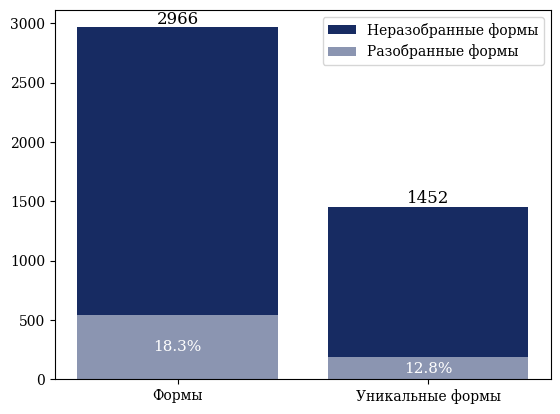

In [17]:
labels = ["Формы", "Уникальные формы"]

covered = [len(coverage), len(set(coverage))]
totals = [len(forms), len(set(forms))]

plt.bar(labels, totals, label="Неразобранные формы", color=base_color)
plt.bar(labels, covered, label="Разобранные формы", color=lighten_color(base_color))

for i, total in enumerate(totals):
    covered_pct = covered[i] / total * 100

    plt.text(
        i,
        covered[i] / 2,
        f"{covered_pct:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=11
    )

    plt.text(
        i,
        total,
        f"{total}",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.legend()
plt.show()

In [4]:
forms = []
gold_standard = []
analyses = []
inf = []
cnt = 0

In [5]:
with open("text1_kibrik.csv", "rt", encoding="utf-8") as f:
    for line in csv.reader(f):
        if line[4] == "my_gloss":
            continue
        form = line[2].replace("=", "").replace("-", "")
        forms.append(form)
        if line[4] not in ("my_gloss", ""):
            form = line[2].replace("=", "").replace("-", "")
            gold_standard.append(line[4])
            analysis = subprocess.run(
                ["hfst-lookup", "analyzer.hfstol"],
                input=form,
                text=True,
                encoding="utf-8",
                capture_output=True
            )
            analyses.append(tuple((a.split("\t")[1] for a in analysis.stdout.strip().splitlines())))

In [6]:
for i in range(len(gold_standard)):
    if gold_standard[i] not in analyses[i]:
        inf.append(tuple((gold_standard[i], analyses[i])))

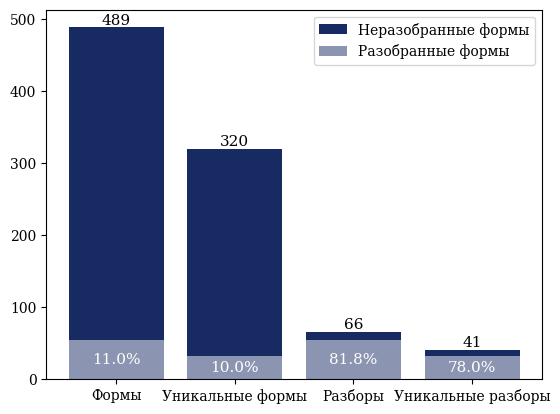

In [9]:
labels = ["Формы", "Уникальные формы", "Разборы", "Уникальные разборы"]

covered = [len(analyses) - len(inf), len(set(analyses)) - len(set(inf)), len(analyses) - len(inf), len(set(analyses)) - len(set(inf))]
totals = [len(forms), len(set(forms)), len(analyses), len(set(analyses))]
not_covered = [totals[i] - covered[i] for i in range(len(totals))]

plt.bar(labels, totals, label="Неразобранные формы", color=base_color)
plt.bar(labels, covered, label="Разобранные формы", color=lighten_color(base_color))

for i, total in enumerate(totals):
    covered_pct = covered[i] / total * 100
    not_covered_pct = not_covered[i] / total * 100

    plt.text(
        i,
        covered[i] / 2,
        f"{covered_pct:.1f}%",
        ha="center",
        va="center",
        color="white",
        fontsize=11
    )

    plt.text(
        i,
        total,
        f"{total}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.legend()
plt.show()

In [15]:
for i, analysis in enumerate(set(inf)):
    print(f"{i + 1}. Gold standard: {analysis[0]}  Analysis: {analysis[1][0]}")

1. Gold standard: жи<PRON>><m>><ept>  Analysis: живва+?
2. Gold standard: жи<PRON>><h><pl>><and>  Analysis: жибела+?
3. Gold standard: жи<PRON>><m>><cit>  Analysis: живкьу+?
4. Gold standard: э<PRON>><h><pl>><upt>  Analysis: эбевахъи+?
5. Gold standard: чара<ADJ>><masd>  Analysis: чаралъир+?
6. Gold standard: чара<ADJ>><masd>><and>  Analysis: чаралъирла+?
7. Gold standard: гьо<PRON>><m>><and>  Analysis: гьовла+?
8. Gold standard: къувата<ADJ>><m>  Analysis: къуватав+?
9. Gold standard: жи<PRON><obl>><obl><m><erg>><ept>  Analysis: инщолъа+?
